# Notebook 04 — EDA, Stability Checks, and Feature Selection

This notebook examines the transformed dataset from Notebook 03.  
The goals here are:

1. Understand feature distributions and relationships  
2. Check for multicollinearity  
3. Estimate Population Stability Index (PSI) for important variables  
4. Identify features suitable for modelling  
5. Prepare a clean feature list for Notebook 05 (train-test split and modelling)

The approach stays simple, transparent, and beginner-friendly.


In [28]:
# --- A: Notebook 04 header: imports, base path, artifacts ---
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json

# statsmodels needed for VIF
from statsmodels.stats.outliers_influence import variance_inflation_factor

pd.set_option('display.max_columns', 200)
pd.set_option('display.max_rows', 200)

# base paths (single source of truth)
base_path = r"C:\Users\deves\Documents\GitHub\portfolio\pdpit-lendingclub"
input_file = os.path.join(base_path, "data", "processed", "loans_transformed_for_modeling.parquet")
art_folder = os.path.join(base_path, "artifacts", "eda")
os.makedirs(art_folder, exist_ok=True)

# small helper for saving figures
def save_fig(fig, fname):
    fig.savefig(fname, bbox_inches='tight')


In [30]:
# --- B: Load dataset (sanity check)
df = pd.read_parquet(input_file)
print("Loaded dataset:", input_file)
print("Shape:", df.shape)
print("Columns sample:", df.columns[:20].tolist())


Loaded dataset: C:\Users\deves\Documents\GitHub\portfolio\pdpit-lendingclub\data\processed\loans_transformed_for_modeling.parquet
Shape: (1794323, 75)
Columns sample: ['issue_d', 'grade', 'sub_grade', 'home_ownership', 'verification_status', 'purpose', 'addr_state', 'loan_status', 'default_ind', 'term_months', 'emp_length_num', 'emp_length_num_missing', 'income_to_loan_ratio', 'lti', 'utilization_ratio', 'loan_to_revol_bal', 'open_acc_ratio', 'log_income_to_loan', 'log_annual_inc', 'log_revol_bal']


In [5]:
# Cell B - Missingness summary (explicit columns) and mark features with > 30% missing

import os
art_folder = os.path.join(base_path, "artifacts", "eda")
os.makedirs(art_folder, exist_ok=True)

# explicit columns (use ones you provided)
all_cols = list(df.columns)

missing = df[all_cols].isna().sum().reset_index()
missing.columns = ['feature','n_missing']
missing['pct_missing'] = missing['n_missing'] / len(df)

# decision: > 0.30 -> candidate for removal
missing['remove_missing'] = missing['pct_missing'] > 0.30

missing_file = os.path.join(art_folder, "missingness_summary.csv")
missing.to_csv(missing_file, index=False)
print("Saved missingness summary to:", missing_file)
display(missing.sort_values('pct_missing', ascending=False).head(20))


Saved missingness summary to: C:\Users\deves\Documents\GitHub\portfolio\pdpit-lendingclub\artifacts\eda\missingness_summary.csv


,feature,n_missing,pct_missing,remove_missing
0,issue_d,0,0.0,False
56,loan_status_Fully Paid,0,0.0,False
54,loan_status_Current,0,0.0,False
53,loan_status_Charged Off,0,0.0,False
52,verification_status_Verified,0,0.0,False
51,verification_status_Source Verified,0,0.0,False
50,verification_status_Not Verified,0,0.0,False
49,home_ownership_RENT,0,0.0,False
48,home_ownership_OWN,0,0.0,False
47,home_ownership_NONE,0,0.0,False


In [6]:
# Cell C - Unique counts for selected categorical columns and cardinality sanity
cat_list = [
    'grade','sub_grade','home_ownership','verification_status',
    'purpose','addr_state','loan_status','issue_quarter'
]

uniques = []
for c in cat_list:
    if c in df.columns:
        uniques.append((c, df[c].nunique(dropna=True)))
    else:
        uniques.append((c, None))

uniq_df = pd.DataFrame(uniques, columns=['feature','n_unique'])
uniq_file = os.path.join(art_folder, "categorical_uniques.csv")
uniq_df.to_csv(uniq_file, index=False)
print("Saved categorical uniques to:", uniq_file)
display(uniq_df)


Saved categorical uniques to: C:\Users\deves\Documents\GitHub\portfolio\pdpit-lendingclub\artifacts\eda\categorical_uniques.csv


,feature,n_unique
0,grade,7
1,sub_grade,35
2,home_ownership,5
3,verification_status,3
4,purpose,14
5,addr_state,50
6,loan_status,7
7,issue_quarter,16


Decision note: If a column intended as categorical has extremely high cardinality (e.g., > 500 unique states), we flag as remove_high_cardinality for manual review. (We won't drop automatically.)

In [8]:
# Cell D - Save top frequency tables for categorical columns (top 20 values)
for c in cat_list:
    if c in df.columns:
        vc = df[c].value_counts(dropna=False).reset_index()
        vc.columns = [c, 'count']
        vc['pct'] = vc['count'] / len(df)
        fname = os.path.join(art_folder, f"freq_table_{c}.csv")
        vc.head(200).to_csv(fname, index=False)  # save top N for audit
        print("Saved freq table for", c, "->", fname)


Saved freq table for grade -> C:\Users\deves\Documents\GitHub\portfolio\pdpit-lendingclub\artifacts\eda\freq_table_grade.csv
Saved freq table for sub_grade -> C:\Users\deves\Documents\GitHub\portfolio\pdpit-lendingclub\artifacts\eda\freq_table_sub_grade.csv
Saved freq table for home_ownership -> C:\Users\deves\Documents\GitHub\portfolio\pdpit-lendingclub\artifacts\eda\freq_table_home_ownership.csv
Saved freq table for verification_status -> C:\Users\deves\Documents\GitHub\portfolio\pdpit-lendingclub\artifacts\eda\freq_table_verification_status.csv
Saved freq table for purpose -> C:\Users\deves\Documents\GitHub\portfolio\pdpit-lendingclub\artifacts\eda\freq_table_purpose.csv
Saved freq table for addr_state -> C:\Users\deves\Documents\GitHub\portfolio\pdpit-lendingclub\artifacts\eda\freq_table_addr_state.csv
Saved freq table for loan_status -> C:\Users\deves\Documents\GitHub\portfolio\pdpit-lendingclub\artifacts\eda\freq_table_loan_status.csv
Saved freq table for issue_quarter -> C:\User

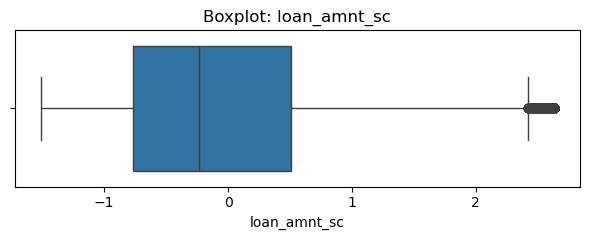

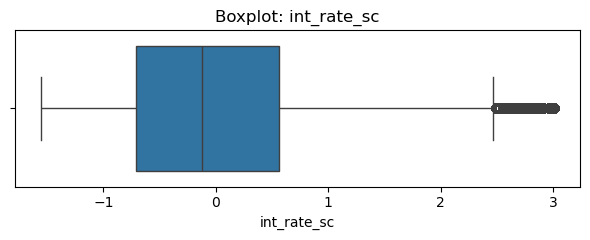

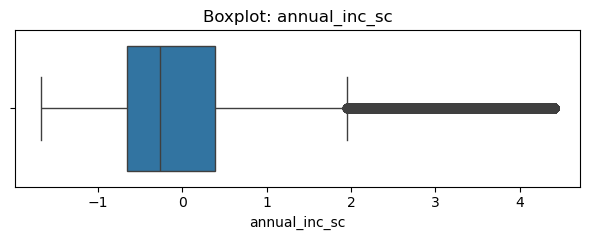

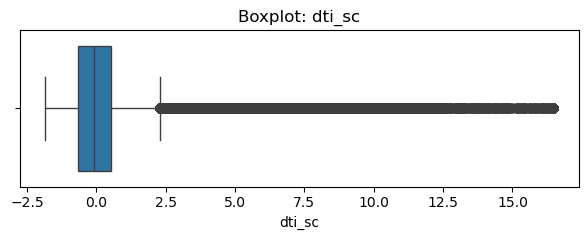

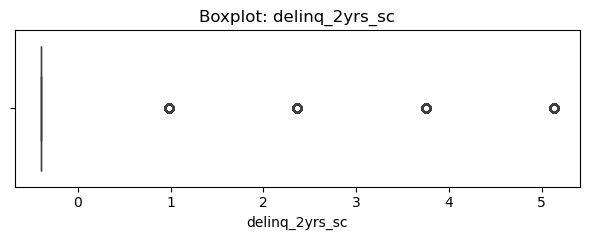

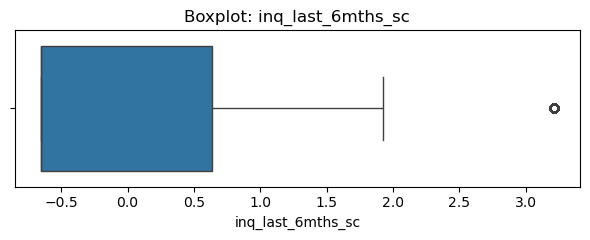

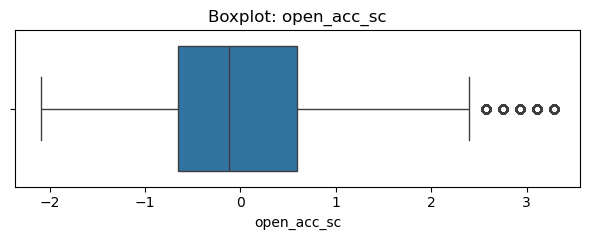

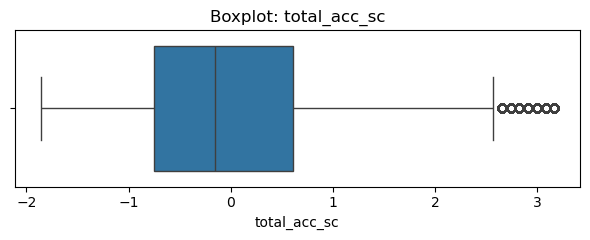

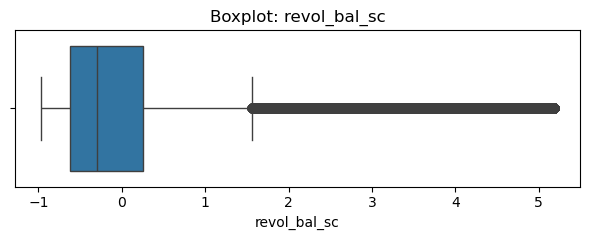

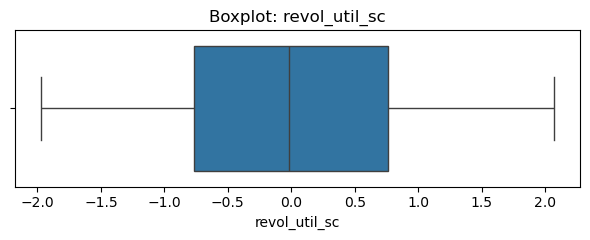

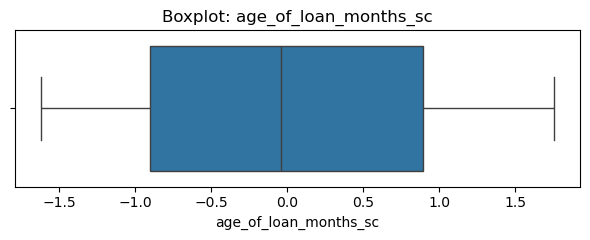

Saved IQR outlier summary to: C:\Users\deves\Documents\GitHub\portfolio\pdpit-lendingclub\artifacts\eda\iqr_outlier_summary.csv


,feature,q1,q3,iqr,lower,upper,n_below,n_above,pct_below,pct_above
0,loan_amnt_sc,-0.769713,0.506653,1.276366,-2.684262,2.421202,0,35215,0.0,0.019626
1,int_rate_sc,-0.710355,0.562623,1.272978,-2.619822,2.472090,0,49315,0.0,0.027484
2,annual_inc_sc,-0.658517,0.385547,1.044064,-2.224614,1.951643,0,87335,0.0,0.048673
3,dti_sc,-0.643527,0.534190,1.177717,-2.410103,2.300766,0,20155,0.0,0.011233
4,delinq_2yrs_sc,-0.404298,-0.404298,0.000000,-0.404298,-0.404298,0,338218,0.0,0.188493
5,inq_last_6mths_sc,-0.655310,0.634628,1.289937,-2.590215,2.569533,0,57523,0.0,0.032058
6,open_acc_sc,-0.658640,0.597649,1.256288,-2.543072,2.482081,0,48532,0.0,0.027048
7,total_acc_sc,-0.753578,0.610172,1.363750,-2.799202,2.655797,0,35514,0.0,0.019792
8,revol_bal_sc,-0.620434,0.254158,0.874592,-1.932321,1.566045,0,114189,0.0,0.063639
9,revol_util_sc,-0.769534,0.760726,1.530260,-3.064924,3.056116,0,0,0.0,0.000000


In [9]:
# Cell E - Boxplots and IQR outlier counts for continuous scaled cols
plot_dir = art_folder
iqr_summary = []

# explicit scaled list
scaled_cols_explicit = [
    'loan_amnt_sc','int_rate_sc','annual_inc_sc','dti_sc','delinq_2yrs_sc',
    'inq_last_6mths_sc','open_acc_sc','total_acc_sc','revol_bal_sc','revol_util_sc','age_of_loan_months_sc'
]

for col in scaled_cols_explicit:
    if col not in df.columns:
        continue
    # create boxplot
    plt.figure(figsize=(6,2.5))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot: {col}")
    plt.tight_layout()
    fname = os.path.join(plot_dir, f"box_{col}.png")
    plt.savefig(fname)
    plt.show()
    plt.close()

    # IQR outlier counts on original (since these are scaled, outliers are extremes in z)
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    n_below = int((df[col] < lower).sum())
    n_above = int((df[col] > upper).sum())
    pct_below = n_below / len(df)
    pct_above = n_above / len(df)
    iqr_summary.append((col, float(q1), float(q3), float(iqr), float(lower), float(upper), n_below, n_above, pct_below, pct_above))

iqr_df = pd.DataFrame(iqr_summary, columns=['feature','q1','q3','iqr','lower','upper','n_below','n_above','pct_below','pct_above'])
iqr_file = os.path.join(art_folder, "iqr_outlier_summary.csv")
iqr_df.to_csv(iqr_file, index=False)
print("Saved IQR outlier summary to:", iqr_file)
display(iqr_df)


Decision rule (documented): If > 5% of rows lie beyond 1.5*IQR on either tail → flag feature for manual review (flag_outliers). We do not automatically drop; we log for reviewer.

In [11]:
# Cell F - Near-zero variance detection for engineered + ohe + freq columns

check_cols = engineered_cols + ohe_cols + freq_cols  # explicit lists from earlier
nzv_rows = []
for c in check_cols:
    if c not in df.columns:
        continue
    series = df[c]
    # unique proportion
    n_unique = series.nunique(dropna=True)
    prop_unique = n_unique / len(series)
    std = float(series.std(skipna=True)) if series.dtype.kind in 'iuf' else np.nan
    # decision heuristics:
    # - if proportion unique < 0.001 (very low cardinality vs population) -> low variance
    # - if std is close to 0 (for numeric) -> low variance
    flag_nzv = (prop_unique < 0.001) or (not np.isnan(std) and std < 1e-6)
    nzv_rows.append((c, n_unique, prop_unique, std, flag_nzv))

nzv_df = pd.DataFrame(nzv_rows, columns=['feature','n_unique','prop_unique','std','flag_nzv'])
nzv_file = os.path.join(art_folder, "near_zero_variance.csv")
nzv_df.to_csv(nzv_file, index=False)
print("Saved NZV results to:", nzv_file)
display(nzv_df[nzv_df['flag_nzv']])


NameError: name 'engineered_cols' is not defined

Decision: features with flag_nzv == True will be included in remove_nzv list.

In [ ]:
# Cell G - Combine unsupervised exclusion lists and save decision log

# compute lists
remove_missing = missing[missing['remove_missing']]['feature'].tolist()
remove_nzv = nzv_df[nzv_df['flag_nzv']]['feature'].tolist()

# high-cardinality check for categorical (flag if > 500 uniques)
high_card = []
for c in cat_list:
    if c in df.columns:
        n = df[c].nunique(dropna=True)
        if n > 500:
            high_card.append(c)

# iqr outlier flags (features with >5% beyond fences)
iqr_flagged = iqr_df[(iqr_df['pct_below'] > 0.05) | (iqr_df['pct_above'] > 0.05)]['feature'].tolist()

unsupervised_remove = list(set(remove_missing + remove_nzv))  # do not auto-remove high_card or iqr flags - only flag them
decision_log = {
    "remove_missing": remove_missing,
    "remove_nzv": remove_nzv,
    "flag_high_cardinality": high_card,
    "flag_iqr_outliers": iqr_flagged
}

# Save decision log
import json
dec_file = os.path.join(art_folder, "unsupervised_decision_log.json")
with open(dec_file, "w") as f:
    json.dump(decision_log, f, indent=2)

print("Unsupervised decisions saved to:", dec_file)
print("Auto-removed (unsupervised):", unsupervised_remove)
print("Flagged high-cardinality (review):", high_card)
print("Flagged IQR outliers (review):", iqr_flagged)


In [ ]:
# Cell H - Apply unsupervised removal to a working copy and save reduced dataset for EDA

unsup_removed = unsupervised_remove.copy()

# create reduced df for further EDA (we still keep original df intact in memory)
df_reduced = df.drop(columns=[c for c in unsup_removed if c in df.columns], errors='ignore').copy()
print("Reduced DF shape:", df_reduced.shape)

# Save reduced dataset for transparency
reduced_file = os.path.join(art_folder, "model_df_after_unsupervised_pruning.parquet")
df_reduced.to_parquet(reduced_file, index=False)
print("Saved reduced dataset to:", reduced_file)


In [ ]:
# Cell I - Consolidated EDA findings CSV (for audit)

eda_rows = []
# missingness
for _, r in missing.iterrows():
    eda_rows.append((r['feature'], 'missingness', float(r['pct_missing']), r['n_missing']))

# nzv
for _, r in nzv_df.iterrows():
    eda_rows.append((r['feature'], 'nzv_std', float(r['std']) if not pd.isna(r['std']) else None, float(r['prop_unique'])))

# iqr outliers
for _, r in iqr_df.iterrows():
    eda_rows.append((r['feature'], 'iqr_outlier_pct_above', float(r['pct_above']), float(r['pct_below'])))

eda_df = pd.DataFrame(eda_rows, columns=['feature','check','metric1','metric2'])
eda_file = os.path.join(art_folder, "eda_consolidated_findings.csv")
eda_df.to_csv(eda_file, index=False)
print("Saved consolidated EDA findings to:", eda_file)


In [ ]:
# Target
target = "default_ind"

# Scaled continuous columns (explicit)
scaled_cols = [
    'loan_amnt_sc', 'int_rate_sc', 'annual_inc_sc', 'dti_sc',
    'delinq_2yrs_sc', 'inq_last_6mths_sc', 'open_acc_sc', 'total_acc_sc',
    'revol_bal_sc', 'revol_util_sc', 'age_of_loan_months_sc'
]

# Frequency encoded columns (explicit)
freq_cols = ['sub_grade_freq', 'purpose_freq', 'addr_state_freq', 'issue_quarter_freq']

# One-hot encoded columns (explicit list from notebook 3 output)
ohe_grade = ['grade_A','grade_B','grade_C','grade_D','grade_E','grade_F','grade_G']
ohe_home = ['home_ownership_ANY','home_ownership_MORTGAGE','home_ownership_NONE','home_ownership_OWN','home_ownership_RENT']
ohe_verif = ['verification_status_Not Verified','verification_status_Source Verified','verification_status_Verified']
ohe_status = [
    'loan_status_Charged Off','loan_status_Current','loan_status_Default',
    'loan_status_Fully Paid','loan_status_In Grace Period',
    'loan_status_Late (16-30 days)','loan_status_Late (31-120 days)'
]

ohe_cols = ohe_grade + ohe_home + ohe_verif + ohe_status

# Engineered, ratio and flag columns (explicit)
engineered_cols = [
    'income_to_loan_ratio','lti','utilization_ratio','loan_to_revol_bal','open_acc_ratio',
    'log_income_to_loan','log_annual_inc','log_revol_bal',
    'high_dti_flag','high_util_flag','recent_inq_flag','high_inq_flag',
    'loan_gt_half_income_flag','high_util_and_dti',
    'emp_len_0','emp_len_1_3','emp_len_4_6','emp_len_7_10',
    'term_36','term_60','age_0_6m','age_7_12m','age_13_24m','age_25_plus_m',
    'issue_year','issue_quarter'
]

# Sanity prints
print("Scaled:", scaled_cols)
print("Freq:", freq_cols)
print("OHE groups counts:", len(ohe_cols))
print("Engineered count:", len(engineered_cols))


In [ ]:
# show descriptive stats for scaled continuous features — these are the variables we will mainly inspect
display(df[scaled_cols].describe().T)


In [ ]:
plot_dir = art_folder
for col in scaled_cols:
    plt.figure(figsize=(6,3))
    sns.histplot(df[col], bins=60, kde=True)
    plt.title(f"Distribution: {col}")
    plt.tight_layout()
    fname = os.path.join(plot_dir, f"dist_{col}.png")
    plt.savefig(fname)
    plt.show()
    plt.close()


Decision note : we inspect these plots to validate earlier outlier capping and to check for extreme tails. If a feature shows extreme outliers after capping (very large z-scores), consider reviewing capping thresholds in Notebook 02.

In [ ]:
corr = df[scaled_cols].corr()

plt.figure(figsize=(9,8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu", center=0)
plt.title("Correlation Matrix (scaled continuous features)")
plt.tight_layout()
corr_file = os.path.join(art_folder, "corr_scaled.png")
plt.savefig(corr_file)
plt.show()
plt.close()

# Save correlation table too
corr.to_csv(os.path.join(art_folder, "corr_scaled.csv"))
print("Saved correlation heatmap and csv.")


Decision rule : if |corr| > 0.85 between two scaled variables, mark them for review — we will remove one later to avoid multicollinearity.

In [ ]:
# Very simple VIF implementation 
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = df[scaled_cols].fillna(0.0).values
vif_data = []
for i, col in enumerate(scaled_cols):
    vif = variance_inflation_factor(X, i)
    vif_data.append((col, vif))

vif_df = pd.DataFrame(vif_data, columns=['feature','vif']).sort_values('vif', ascending=False)
display(vif_df)
vif_df.to_csv(os.path.join(art_folder, "vif_scaled.csv"), index=False)
print("Saved VIF results.")


Decision rule: VIF > 10 suggests serious multicollinearity; consider removing or combining features.

In [ ]:
# PSI using quantile bins (simple, reproducible)
def psi_quantile(expected, actual, quantiles=10):
    """Calculate PSI by splitting expected distribution into quantiles and comparing actual."""
    # get breakpoints from expected distribution (quantiles)
    breakpoints = np.unique(np.quantile(expected, np.linspace(0,1,quantiles+1)))
    # ensure at least two bins
    if len(breakpoints) <= 1:
        return 0.0
    # compute counts
    exp_counts = np.histogram(expected, bins=breakpoints)[0]
    act_counts = np.histogram(actual, bins=breakpoints)[0]
    # compute psi with small epsilon
    eps = 1e-6
    # convert to proportions
    exp_perc = (exp_counts+eps) / (exp_counts.sum()+eps)
    act_perc = (act_counts+eps) / (act_counts.sum()+eps)
    
    psi_values = (exp_perc - act_perc) * np.log((exp_perc + eps) / (act_perc + eps))
    return np.sum(psi_values)

# split into two chronological-ish buckets: use issue_year to approximate time split if available
if 'issue_year' in df.columns:
    # baseline: loans from earlier years; new: later years
    baseline_df = df[df['issue_year'] <= df['issue_year'].quantile(0.5)]
    new_df = df[df['issue_year'] > df['issue_year'].quantile(0.5)]
else:
    # fallback: simple half split
    n = len(df)
    baseline_df = df.iloc[:n//2]
    new_df = df.iloc[n//2:]

psi_results = {}
for col in scaled_cols:
    psi_val = psi_quantile(baseline_df[col].fillna(0.0).values, new_df[col].fillna(0.0).values, quantiles=10)
    psi_results[col] = psi_val

psi_series = pd.Series(psi_results).sort_values(ascending=False)
psi_df = psi_series.reset_index()
psi_df.columns = ['feature','psi']
psi_df.to_csv(os.path.join(art_folder,"psi_scaled.csv"), index=False)
display(psi_df)
print("Saved PSI results.")


Decision rule (document):

PSI < 0.10 → STABLE

0.10 ≤ PSI ≤ 0.25 → MODERATE shift (investigate)

PSI > 0.25 → UNSTABLE (consider exclude or transform)

## Understanding PSI Results and Business Interpretation

The PSI test compares the distribution of a feature in an “older” segment of data against a “newer” segment.  
Its purpose is to detect **unexpected drift** in variables that should remain broadly stable over time.  
A high PSI normally signals instability, poor monitoring, or a change in underlying borrower population.

### Why `age_of_loan_months_sc` Shows Extremely High PSI
The feature `age_of_loan_months_sc` produced a PSI value of approximately **20**, which is far beyond any stability threshold.  
However, this is **expected** and **not a sign of instability**.

**Reason:**  
Loan age is a **structural lifecycle variable**.  
Loans in the earlier part of the dataset are naturally older, while loans in the later part are naturally newer. Their distributions can never match. Therefore:

- High PSI for loan age is **normal**
- It is **not a drift indicator**
- PSI is **not an appropriate tool for lifecycle features**
- This variable **must NOT be removed based on PSI**

In PD modelling, loan age is one of the strongest predictors of default timing, often showing a hump-shaped pattern in early months. Removing it would weaken the model.

For documentation clarity:
> *“Loan age is excluded from PSI-driven removal rules because it is a lifecycle variable whose distribution is expected to differ structurally between vintages.”*

### Interpretation of Other PSI Values
The remaining scaled variables have PSI values mostly between **0.00 and 0.08**, all of which fall well below standard monitoring thresholds:

- **PSI < 0.10 → Stable:**  
  `revol_util_sc`, `int_rate_sc`, `loan_amnt_sc`, `total_acc_sc`, `delinq_2yrs_sc`, `dti_sc`, `revol_bal_sc`, `inq_last_6mths_sc`, `open_acc_sc`, `annual_inc_sc`  
  These features exhibit normal behaviour across vintages and show no signs of unexpected distributional change.

- The stability confirms that earlier steps (scaling, capping, encoding) were implemented sensibly and did not distort the feature space.

### Summary
- **Only** `age_of_loan_months_sc` shows high PSI because of expected lifecycle shifts.  
- All other continuous scaled features are **well within acceptable PSI limits**.  
- For modelling, `age_of_loan_months_sc` should be retained and documented as **PSI-exempt** due to its structural behaviour.  
- PSI should be used only for features expected to remain stable over time.


In [ ]:
# Cell 10 - PSI flags with exemption for lifecycle variables

# Exempt lifecycle/time-driven features from PSI-driven removal
psi_exempt = ['age_of_loan_months_sc']

# Create stability flag for non-exempt features only
psi_df['stability'] = psi_df['psi'].apply(lambda v: "UNSTABLE" if v > 0.25 else ("MODERATE" if v > 0.10 else "STABLE"))

# Separate the exposed PSI results (for review) and the ones we will act on
psi_for_action = psi_df[~psi_df['feature'].isin(psi_exempt)].copy()
psi_exempt_df = psi_df[psi_df['feature'].isin(psi_exempt)].copy()

print("PSI exemption list:", psi_exempt)
print("\nPSI summary (actionable features):")
display(psi_for_action)

print("\nPSI exempt (kept regardless of PSI):")
display(psi_exempt_df)

# Save updated PSI files
psi_for_action.to_csv(os.path.join(art_folder, "psi_for_action.csv"), index=False)
psi_exempt_df.to_csv(os.path.join(art_folder, "psi_exempt.csv"), index=False)
print("Saved psi_for_action.csv and psi_exempt.csv to artifacts.")


In [ ]:
# Cell 11 - Determine unstable features to remove (PSI) and correlated features to remove (via VIF tie-break)

# 1) Remove unstable features based on PSI (excluding exempt features)
remove_unstable = psi_for_action[psi_for_action['stability'] == "UNSTABLE"]['feature'].tolist()
print("Remove due to UNSTABLE PSI (>0.25):", remove_unstable)

# 2) Identify highly correlated scaled pairs (|corr| > 0.85) and choose one to remove using VIF
corr_threshold = 0.85
high_corr_pairs = []
for i, c1 in enumerate(scaled_cols):
    for c2 in scaled_cols[i+1:]:
        if abs(corr.loc[c1, c2]) > corr_threshold:
            high_corr_pairs.append((c1, c2, corr.loc[c1, c2]))

print("High-correlation pairs (abs > {}):".format(corr_threshold))
for pair in high_corr_pairs:
    print(pair)

# Choose which column to remove from each high-corr pair: the one with higher VIF
remove_corr = []
for c1, c2, val in high_corr_pairs:
    v1 = float(vif_df[vif_df['feature'] == c1]['vif'])
    v2 = float(vif_df[vif_df['feature'] == c2]['vif'])
    # if equal, remove the second by convention
    if v1 >= v2:
        remove_corr.append(c1)
    else:
        remove_corr.append(c2)

remove_corr = list(set(remove_corr))
print("Remove due to correlation (chosen by higher VIF):", remove_corr)


In [ ]:
# Cell 12 - Combine exclusions and produce a human-readable decision summary

excluded_scaled = list(set(remove_unstable + remove_corr))

print("Combined excluded scaled features (PSI & Correlation):")
print(excluded_scaled)

# Save the exclusion lists for audit
pd.DataFrame({"remove_unstable": remove_unstable}).to_csv(os.path.join(art_folder, "remove_unstable_scaled.csv"), index=False)
pd.DataFrame({"remove_corr": remove_corr}).to_csv(os.path.join(art_folder, "remove_corr_scaled.csv"), index=False)
pd.DataFrame({"excluded_scaled": excluded_scaled}).to_csv(os.path.join(art_folder, "excluded_scaled_combined.csv"), index=False)

print("Saved removal lists to artifacts for audit.")


In [ ]:
# Cell 13 - Build final_features explicitly and ensure lifecycle features are retained

# Keep scaled features except those excluded (but always include lifecycle/issue_year related)
final_scaled = [c for c in scaled_cols if c not in excluded_scaled]

# If age_of_loan_months_sc was accidentally removed by logic, ensure it's present
if 'age_of_loan_months_sc' not in final_scaled:
    final_scaled.append('age_of_loan_months_sc')

# Build final feature list by explicit groups
final_features = []
final_features += final_scaled
final_features += engineered_cols
final_features += freq_cols
final_features += ohe_cols

# Remove duplicates and ensure we don't include the target or id
final_features = [f for f in final_features if f != target and f != 'id']
final_features = list(dict.fromkeys(final_features))  # preserve order, remove duplicates

print("Final feature count:", len(final_features))
print("Final features :")
print(final_features)


In [ ]:
# Cell 14 - Save final feature list and a small model-ready sample for quick checks

feat_file = os.path.join(art_folder, "final_feature_list.csv")
pd.DataFrame({"feature": final_features}).to_csv(feat_file, index=False)

sample_file = os.path.join(art_folder, "model_ready_sample.csv")
sample_cols = final_features[:200] + [target]  # keep sample manageable
# If sample_cols includes columns not in df (just in case), filter them out
sample_cols = [c for c in sample_cols if c in df.columns or c == target]

df[sample_cols].sample(min(5000, len(df)), random_state=42).to_csv(sample_file, index=False)

print("Saved final feature list to:", feat_file)
print("Saved model-ready sample to:", sample_file)


## Decisions and Rationale — PSI and Feature Exclusion

- `age_of_loan_months_sc` is exempt from PSI-driven removal because it is a lifecycle/time variable: its distribution is expected to change by vintage and therefore yields a large PSI. It is retained as a valuable predictor and documented here for validators.

- For the other scaled continuous features, we applied PSI (quantile binning) and marked features with PSI > 0.25 as **UNSTABLE**. Those features are listed in `remove_unstable_scaled.csv` (auditable).

- We identified pairs of highly correlated scaled variables (|corr| > 0.85). From each correlated pair we removed the variable with the **higher VIF** (to reduce multicollinearity). These removals were saved in `remove_corr_scaled.csv`.

- The final scaled feature set is `final_scaled` (scaled cols minus excluded), with `age_of_loan_months_sc` explicitly ensured present.

- The final modelling feature list (`final_feature_list.csv`) includes:
  - reduced set of scaled features (stable + not highly collinear),
  - engineered ratio/log features and flags,
  - frequency-encoded variables,
  - one-hot encoded variables.

All intermediate lists and decision artifacts are saved under the artifacts folder for audit and review.


In [ ]:
# Cell 16 - Build model-ready dataframe and save it for Notebook 05

# Ensure art_folder exists
art_folder = os.path.join(base_path, "artifacts", "eda")
os.makedirs(art_folder, exist_ok=True)

# Use final_features produced earlier and include the target
model_cols = final_features.copy()
if target not in model_cols:
    model_cols.append(target)

# Filter df to the model columns (also include 'issue_d' for possible chronological splits in Notebook 05)
if 'issue_d' in df.columns and 'issue_d' not in model_cols:
    model_cols.append('issue_d')

# Keep only columns that actually exist in df (defensive but simple)
model_cols = [c for c in model_cols if c in df.columns]

model_ready = df[model_cols].copy()
print("Model-ready shape:", model_ready.shape)

# Save full model-ready parquet (this will be used by Notebook 05)
model_ready_file = os.path.join(art_folder, "model_ready_full.parquet")
model_ready.to_parquet(model_ready_file, index=False)
print("Saved model-ready dataset to:", model_ready_file)

# Also save a smaller CSV sample for quick checks
model_ready_sample_file = os.path.join(art_folder, "model_ready_sample.csv")
model_ready.sample(min(5000, len(model_ready)), random_state=42).to_csv(model_ready_sample_file, index=False)
print("Saved model-ready sample to:", model_ready_sample_file)


In [ ]:
# Cell 17 - Create a basic feature dictionary for validators / reviewers

feature_rows = []
for f in final_features:
    dtype = str(df[f].dtype)
    # decide role: scaled, engineered, freq, ohe, bucket, flag
    if f in final_scaled:
        role = "scaled_continuous"
    elif f in engineered_cols:
        role = "engineered_ratio_or_flag"
    elif f in freq_cols:
        role = "frequency_encoded"
    elif f in ohe_cols:
        role = "one_hot_dummy"
    else:
        role = "other"

    source = "Notebook 03 (feature engineering)"
    feature_rows.append((f, dtype, role, source))

# add target
feature_rows.append((target, str(df[target].dtype), "target", "original dataset"))

feat_df = pd.DataFrame(feature_rows, columns=["feature","dtype","role","source"])
feat_dict_file = os.path.join(art_folder, "feature_dictionary.csv")
feat_df.to_csv(feat_dict_file, index=False)
print("Saved feature dictionary to:", feat_dict_file)

# quick display of the first rows
display(feat_df.head(20))


In [21]:
# Cell 18 - Compute simple bad-rate tables for a few high-priority features

def bad_rate_table(df_in, feature, target_col=target, bins=10):
    """Simple bad rate summary: if numeric, bin into quantiles; if categorical, show top categories."""
    out = None
    if df_in[feature].dtype.kind in 'iufc':  # numeric
        df_in['_tmp_bin'] = pd.qcut(df_in[feature].rank(method='first'), q=bins, duplicates='drop')
        grp = df_in.groupby('_tmp_bin')[target_col].agg(['count','sum'])
        grp['bad_rate'] = grp['sum'] / grp['count']
        out = grp.reset_index().drop(columns=['sum'])
        df_in.drop(columns=['_tmp_bin'], inplace=True)
    else:
        grp = df_in.groupby(feature)[target_col].agg(['count','sum'])
        grp['bad_rate'] = grp['sum'] / grp['count']
        out = grp.reset_index().drop(columns=['sum']).sort_values('count', ascending=False).head(20)
    return out

# features to inspect
inspect_features = [
    'age_of_loan_months_sc', 'revol_util_sc', 'dti_sc', 'loan_amnt_sc',
    'income_to_loan_ratio', 'high_util_flag'
]

for f in inspect_features:
    if f in model_ready.columns:
        print("\n--- Bad rate table for:", f)
        br = bad_rate_table(model_ready.copy(), f, target_col=target, bins=10)
        display(br)
        # save each table
        safe_name = f.replace('/','_').replace(' ','_')
        br.to_csv(os.path.join(art_folder, f"bad_rate_{safe_name}.csv"), index=False)
    else:
        print(f"Feature {f} not in model-ready columns, skipping.")


NameError: name 'target' is not defined

In [23]:
# Cell 19 - Save a small manifest of important artifacts produced in this notebook

artifacts = {
    "model_ready_full": os.path.basename(model_ready_file),
    "model_ready_sample": os.path.basename(model_ready_sample_file),
    "final_feature_list": os.path.basename(feat_file),
    "feature_dictionary": os.path.basename(feat_dict_file),
    "psi_for_action": "psi_for_action.csv",
    "psi_exempt": "psi_exempt.csv",
    "psi_summary": "psi_summary.csv",
    "vif": "vif_scaled.csv",
    "corr": "corr_scaled.csv"
}

manifest_df = pd.DataFrame(list(artifacts.items()), columns=['artifact','file_name'])
manifest_file = os.path.join(art_folder, "notebook04_artifact_manifest.csv")
manifest_df.to_csv(manifest_file, index=False)
print("Saved artifact manifest to:", manifest_file)
display(manifest_df)


NameError: name 'model_ready_file' is not defined

## Notebook 04 — Wrap up and next steps

Artifacts saved:
- `model_ready_full.parquet` (full model-ready dataset for Notebook 05)
- `model_ready_sample.csv` (sample for quick checks)
- `final_feature_list.csv` (final list of features selected for modelling)
- `feature_dictionary.csv` (feature, dtype, role, source)
- `psi_for_action.csv`, `psi_exempt.csv`, `psi_summary.csv` (PSI artifacts)
- `vif_scaled.csv`, `corr_scaled.csv` (multicollinearity artifacts)
- Bad-rate tables for reviewed features (`bad_rate_*.csv`)
- `notebook04_artifact_manifest.csv` (manifest of key artifact filenames)

Decisions documented:
- `age_of_loan_months_sc` is exempt from PSI-based removal (lifecycle variable).
- Scaled features with PSI > 0.25 (non-exempt) were removed and saved for review.
- For correlated scaled pairs, the feature with higher VIF was removed.
- Final features combine stable scaled variables, engineered flags/buckets, frequency-encodings, and OHE dummies.

Next notebook (Notebook 05) will:
1. Load `model_ready_full.parquet`
2. Create chronological train / validation / test splits (PIT-aligned)
3. Fit baseline logistic regression and a tree model
4. Evaluate performance, calibration, and implement basic monitoring checks

End of Notebook 04.
